## **Denoising Autoencoders**
##### We'll use the MNIST dataset to compare results between a vanilla autoencoder and denoising autoencoder. Specifically try to analyse what kind of features are extracted by the different auto-encoders and try to draw some conclusions based on it.

In [1]:
import keras
import numpy as np
from keras.datasets import mnist
from keras import layers

In [63]:
(x_train, _), (x_test, _)=mnist.load_data()
x_train.shape

(60000, 28, 28)

In [3]:
import matplotlib.pyplot as plt

### Visialising the dataset

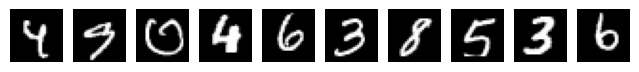

In [65]:
fig, ax=plt.subplots(nrows=1, ncols=10, sharex=True, sharey=True, figsize=(8,8))
rand_obj=np.random.RandomState(123)
for i in ax.flat:   #ax.flat returns a 1-d iterator over the numpy array, iterates as if the array is a 1d array
    img=rand_obj.randint(x_train.shape[0])  # 28,28 array
    i.imshow(x_train[img],cmap='gray', vmin=0, vmax=255) #default rendering of matplotlib renders gray ad blue and white as green
    # cmap changes that
    i.set_axis_off()

### Normalise and flatten out the dataset
- All images are 8-bit grayscale, thus their pixel values will lie between 0 and 255, we'll normalise these pixel values to lie between 0 and 1.
- flatten out each of the 60K datapoints to give a 60k, 784 sized matrix


In [75]:
x_train=x_train.astype('float32')/255   #.astype function convert the given dataset's elements tot the specifided type.
x_test=x_test.astype('float32')/255
x_train=x_train.reshape((60000, 784))
x_test=x_test.reshape((10000, 784))

### Adding noise to the training data
The noise introduced is such that with a probability 'q' it zeros the input.

In [6]:
def add_noise(X, q):
    a=X.shape[0]
    b=X.shape[1]
    # we want to put zeros at exactly b/q places in the input vectors
    noise=np.zeros((b,), dtype=bool)
    noise[0:int(b*q)]=1
    noise=noise+np.zeros((a,b), dtype=bool) # noise array is now broadcasted to 'a' identical vectors of size (b,)
    
    # shuffle each individual vector randomly
    rng = np.random.default_rng()   
    '''np.randomgenerator object, just like a randomstate object but w more functionalities'''
    noise= rng.permuted(noise, axis=1)
    
    #add noise to the input data
    X=X.flatten()
    X[noise.flatten()]=0
    X=X.reshape((a,b))
    return X

In [7]:
#function test
rng = np.random.default_rng()
a=np.arange(0,20, dtype=int).reshape((4,5))

'cant be used with np.random.RandomState'
b=rng.permuted(a, axis=-1)
b
c=add_noise(a, .4)
print(a,'\n',c)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]] 
 [[ 0  1  2  3  0]
 [ 5  0  7  0  9]
 [10 11  0  0 14]
 [15 16 17  0  0]]


In [8]:
x_noise25=add_noise(x_train, .25)
x_noise50=add_noise(x_train, .50)

### Building the autoencoder model
- the model consists of two parts: 1. the encoder and 2. the decoder
- the encoder consists of the following layers 1. a dense hidden layer which returns an encoding of the input data 
- the decoder consists of: 1) a dense output layer, same size of that of the input layer, aims to reconstruct the input.

In [56]:
def autoencoder():
    model= keras.Sequential([
    keras.Input(shape=(784,)),
    keras.layers.Dense(units=100, activation='sigmoid', bias_initializer='zeros'),
    keras.layers.Dense(units=784, activation='sigmoid', bias_initializer='zeros')
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

### Training and saving the models
- keras.models.save(): 
saves the entire model i.e architecture, trained weights, optimiser, loss, etc. We can resume training from the point we left.
- keras.models.to_json(): saves only the architecture in a json string
- we can also save the model architecture into diff string formats like YAML.

In [82]:
from keras.models import load_model
i=0
for X in [x_train, x_noise25, x_noise50]:
    model=autoencoder()
    model.fit(X, x_train, epochs=10, validation_data=(x_test,x_test))  #default batch size of 32 is being used
    model.save('X_noise{i}.h5'.format(i=i))
    i=i+25

Epoch 1/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0431 - val_loss: 0.0248
Epoch 2/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0193 - val_loss: 0.0146
Epoch 3/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0126 - val_loss: 0.0106
Epoch 4/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0096 - val_loss: 0.0084
Epoch 5/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0079 - val_loss: 0.0070
Epoch 6/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0064 - val_loss: 0.0056
Epoch 7/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0052 - val_loss: 0.0046
Epoch 8/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0043 - val_loss: 0.0040
Epoch 9/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 10/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.003

### Loading the models
- We'll now try to interpret what the diff autoencoders have learnt
- We'll observe the input for which each hidden neuron is activated(outputs value ~ 1) and plot these 100 input images for each model.
- the input Xi for which the ith neuron is activated can be given by wts[:,i]/norm(wts[:,i]). (just maximise Xi.wts[:,i])
- this will help us identify which autoencoder is actually extracting the important features from the input data and which one relies mostly on identity encoding.


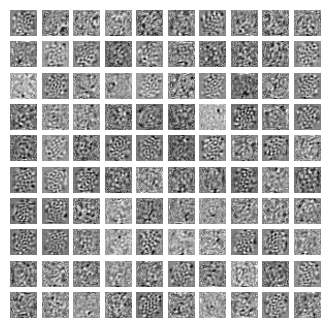

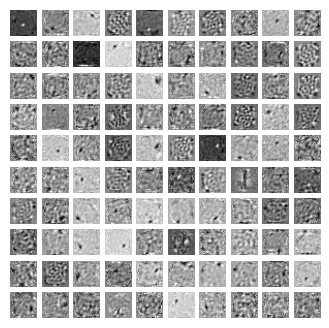

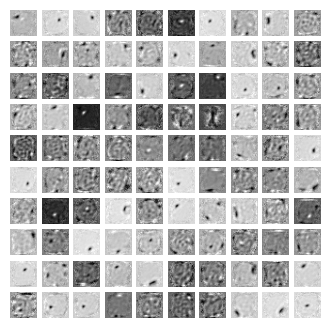

In [83]:
from keras.models import load_model
for i in range(0,75,25):
    model=load_model('X_noise{i}.h5'.format(i=i))
    wts=model.get_weights()[0]  # corresponds to weights(excl. biases) between input and hidden rep
    fig, ax=plt.subplots(nrows=10, ncols=10, sharex=True, sharey=True, figsize=(4,4))
    c=0
    for j in ax.flat:
        w=wts[:,c]
        w=w/np.linalg.norm(w) #computes the euclidean distance by default
        j.imshow(w.reshape((28,28)),cmap='gray')
        j.set_axis_off()
        c=c+1

- Each image at (i,j) in each plot shows what input will fire the corresponding neuron in the hidden representation
- These indirectly show what features are extracted by the respective autoencoder
- Hidden rep. neurons of the one with 50% noise are activated only for very specific inputs for eg- if the input image has a specific curve then we can approximately determine which of the hidden rep. neurons would have been active for that input.
- Using noisy data to train an autoencoder forces it to learn the actually important features of the input data rather than relying on identity mappings in the hidden representation. 

#### Visually comparing results on the test data

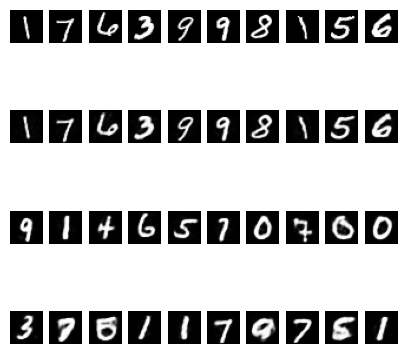

In [84]:
fig, ax=plt.subplots(nrows=4, ncols=10, sharex=True, sharey=True, figsize=(5,5))
rand_obj=np.random.RandomState(123)
it=ax.flat
for j in range(0,75,25):
    model=load_model('X_noise{i}.h5'.format(i=j))
    for i in range(10):   #ax.flat returns a 1-d iterator over the numpy array, iterates as if the array is a 1d array
        img=rand_obj.randint(x_test.shape[0])  # 28,28 array
        if(j==0):
            it[i].imshow(x_test[img].reshape((28,28)),cmap='gray')
            it[i].set_axis_off()
            
        reconstruction=model(x_test[img].reshape(1,784))
        it[i+10*((j//25)+1)].imshow(np.array(reconstruction, dtype=np.float32).reshape((28,28)),cmap='gray')
        it[i+10*((j//25)+1)].set_axis_off()

In [ ]:
model=load_model('X_noise0.h5')
X_noise0=model.get_weights()
model.summary()
print(X_noise0[0].shape,
X_noise0[1].shape,
X_noise0[2].shape,
X_noise0[3].shape)

Model: "sequential_18"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_36 (Dense)            (None, 100)               78500     
                                                                 
 dense_37 (Dense)            (None, 784)               79184     
                                                                 
Total params: 157,684
Trainable params: 157,684
Non-trainable params: 0
_________________________________________________________________
(784, 100) (100,) (100, 784) (784,)
